In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image, display, HTML # for image rendering in html output

In [7]:
# To Do: write a try/catch block to load the given dataset
try:
    print("Loading dataset...")
    data = pd.read_csv("ResearchInformation3.csv")
    print("\tDataset loaded!")
except Exception as exception:
    print(f"ERROR: Unable to load dataset: {exception}")

Loading dataset...
	Dataset loaded!


In [8]:
data.info()
# no null values!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Department   493 non-null    object 
 1   Gender       493 non-null    object 
 2   HSC          493 non-null    float64
 3   SSC          493 non-null    float64
 4   Income       493 non-null    object 
 5   Hometown     493 non-null    object 
 6   Computer     493 non-null    int64  
 7   Preparation  493 non-null    object 
 8   Gaming       493 non-null    object 
 9   Attendance   493 non-null    object 
 10  Job          493 non-null    object 
 11  English      493 non-null    int64  
 12  Extra        493 non-null    object 
 13  Semester     493 non-null    object 
 14  Last         493 non-null    float64
 15  Overall      493 non-null    float64
dtypes: float64(4), int64(2), object(10)
memory usage: 61.8+ KB


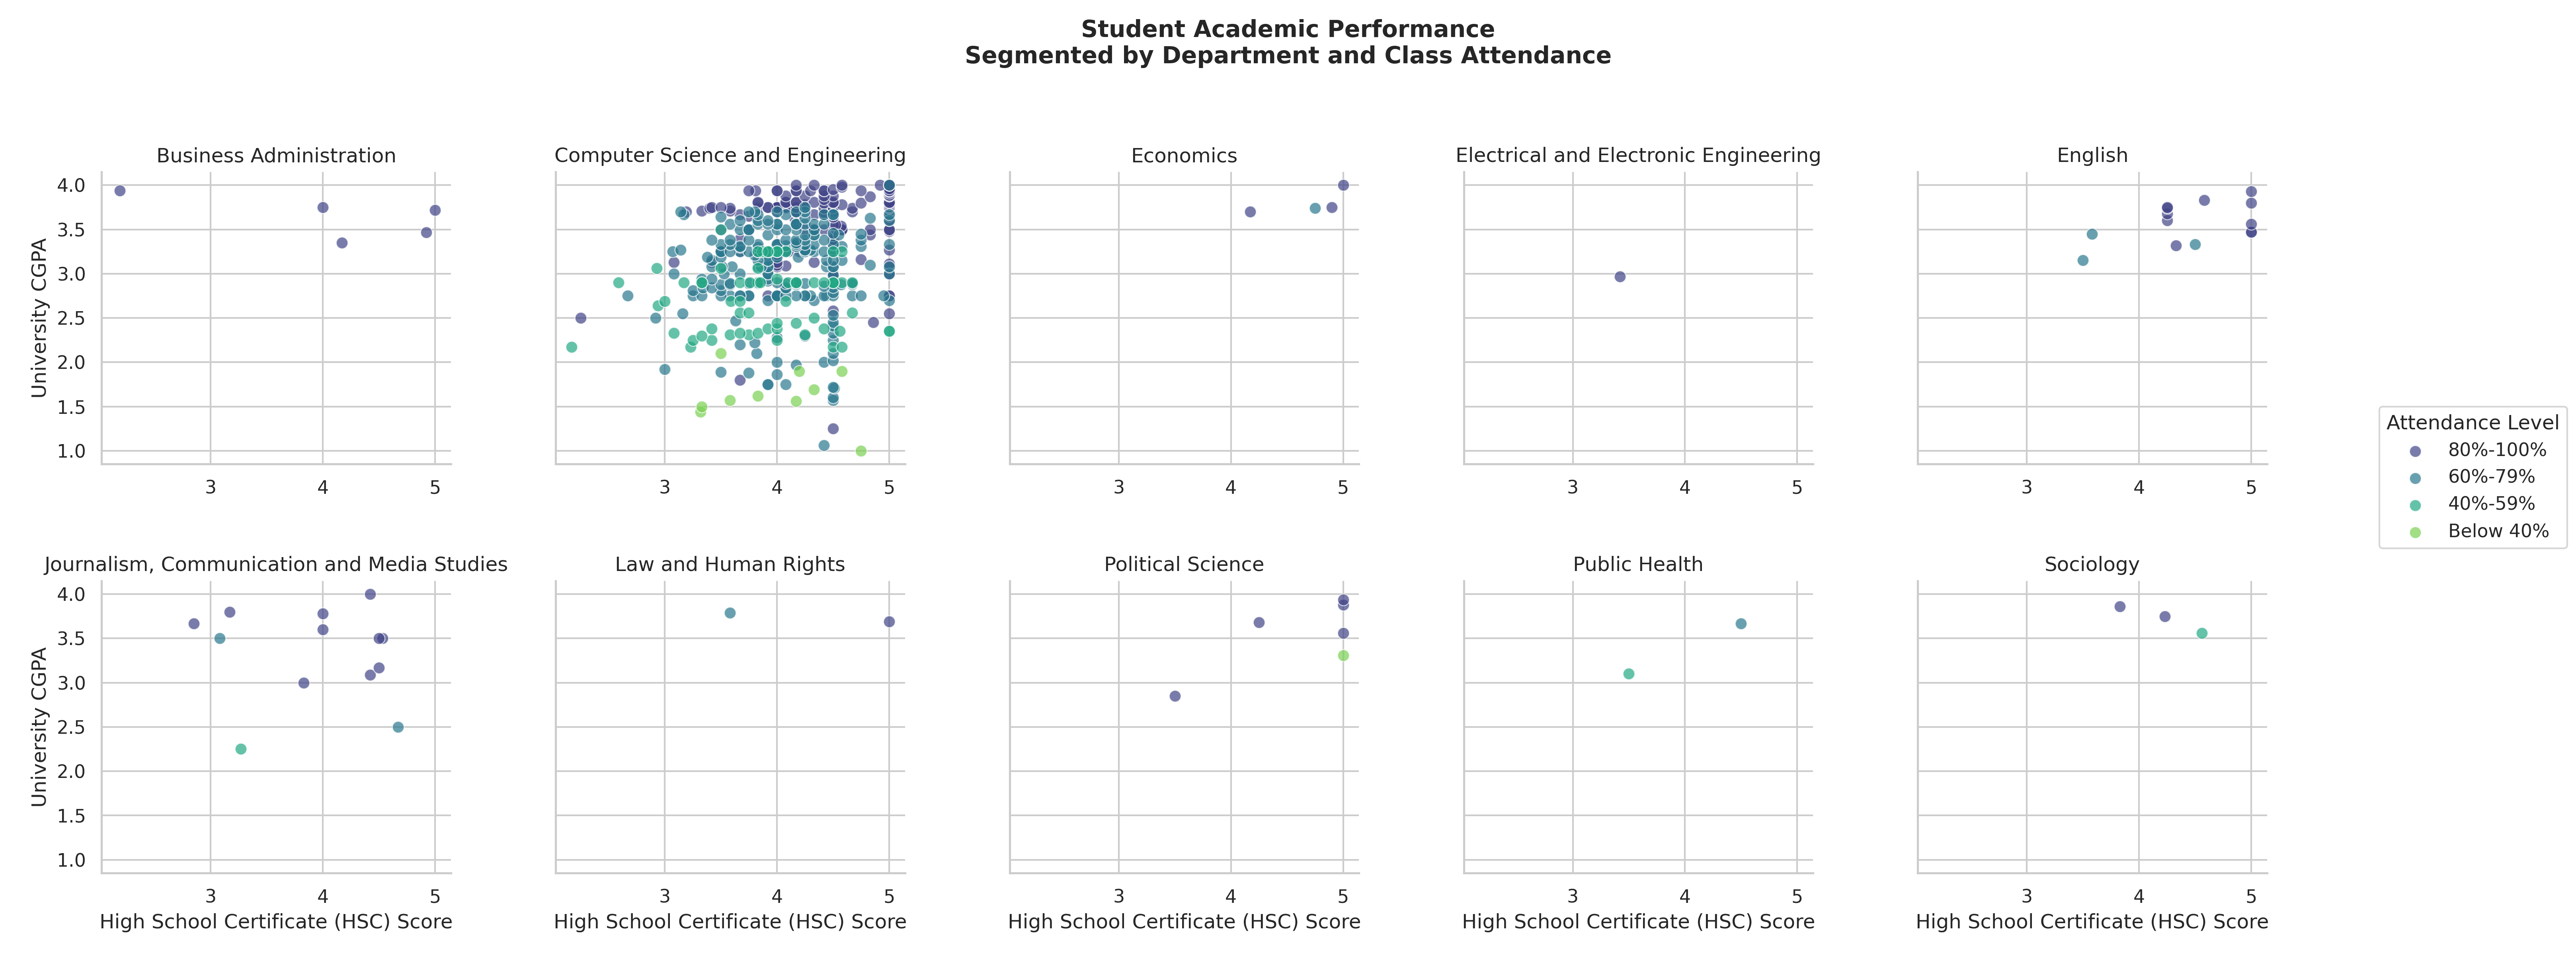

In [9]:
# exploratory
sns.set_theme(style="whitegrid")

# set up a facet grid for many side-by-side charts, use attendance for hue
attendance_order = ["80%-100%", "60%-79%", "40%-59%", "Below 40%"]
g = sns.FacetGrid(
    data, 
    col="Department", 
    hue="Attendance",
    hue_order=attendance_order,
    palette="viridis", 
    col_wrap=5, 
    height=4, 
    aspect=1
)

# for x-axis labels on all charts
for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

# scatter plot for each panel to look for correlations
g.map(sns.scatterplot, "HSC", "Overall", alpha=0.7, edgecolor='w', s=50)
g.set_axis_labels("High School Certificate (HSC) Score", "University CGPA")
g.set_titles(template="{col_name}")

# make sure legend doesn't overlap charts
g.add_legend(
    title="Attendance Level", 
    loc="center right", 
    frameon=True
)

plt.subplots_adjust(top=0.82, right=0.88, hspace=0.4, wspace=0.3)

g.fig.suptitle(
    'Student Academic Performance\nSegmented by Department and Class Attendance', 
    fontsize=14, 
    weight='bold'
)

# save and display!
image_name = "exploratory"
plt.savefig(f"output/{image_name}.png", dpi=300)
plt.close()
display(Image(filename=f"output/{image_name}.png"))

  Attendance   Overall
0   80%-100%  3.581635
1    60%-79%  3.027014
2    40%-59%  2.723077
3  Below 40%  1.628000


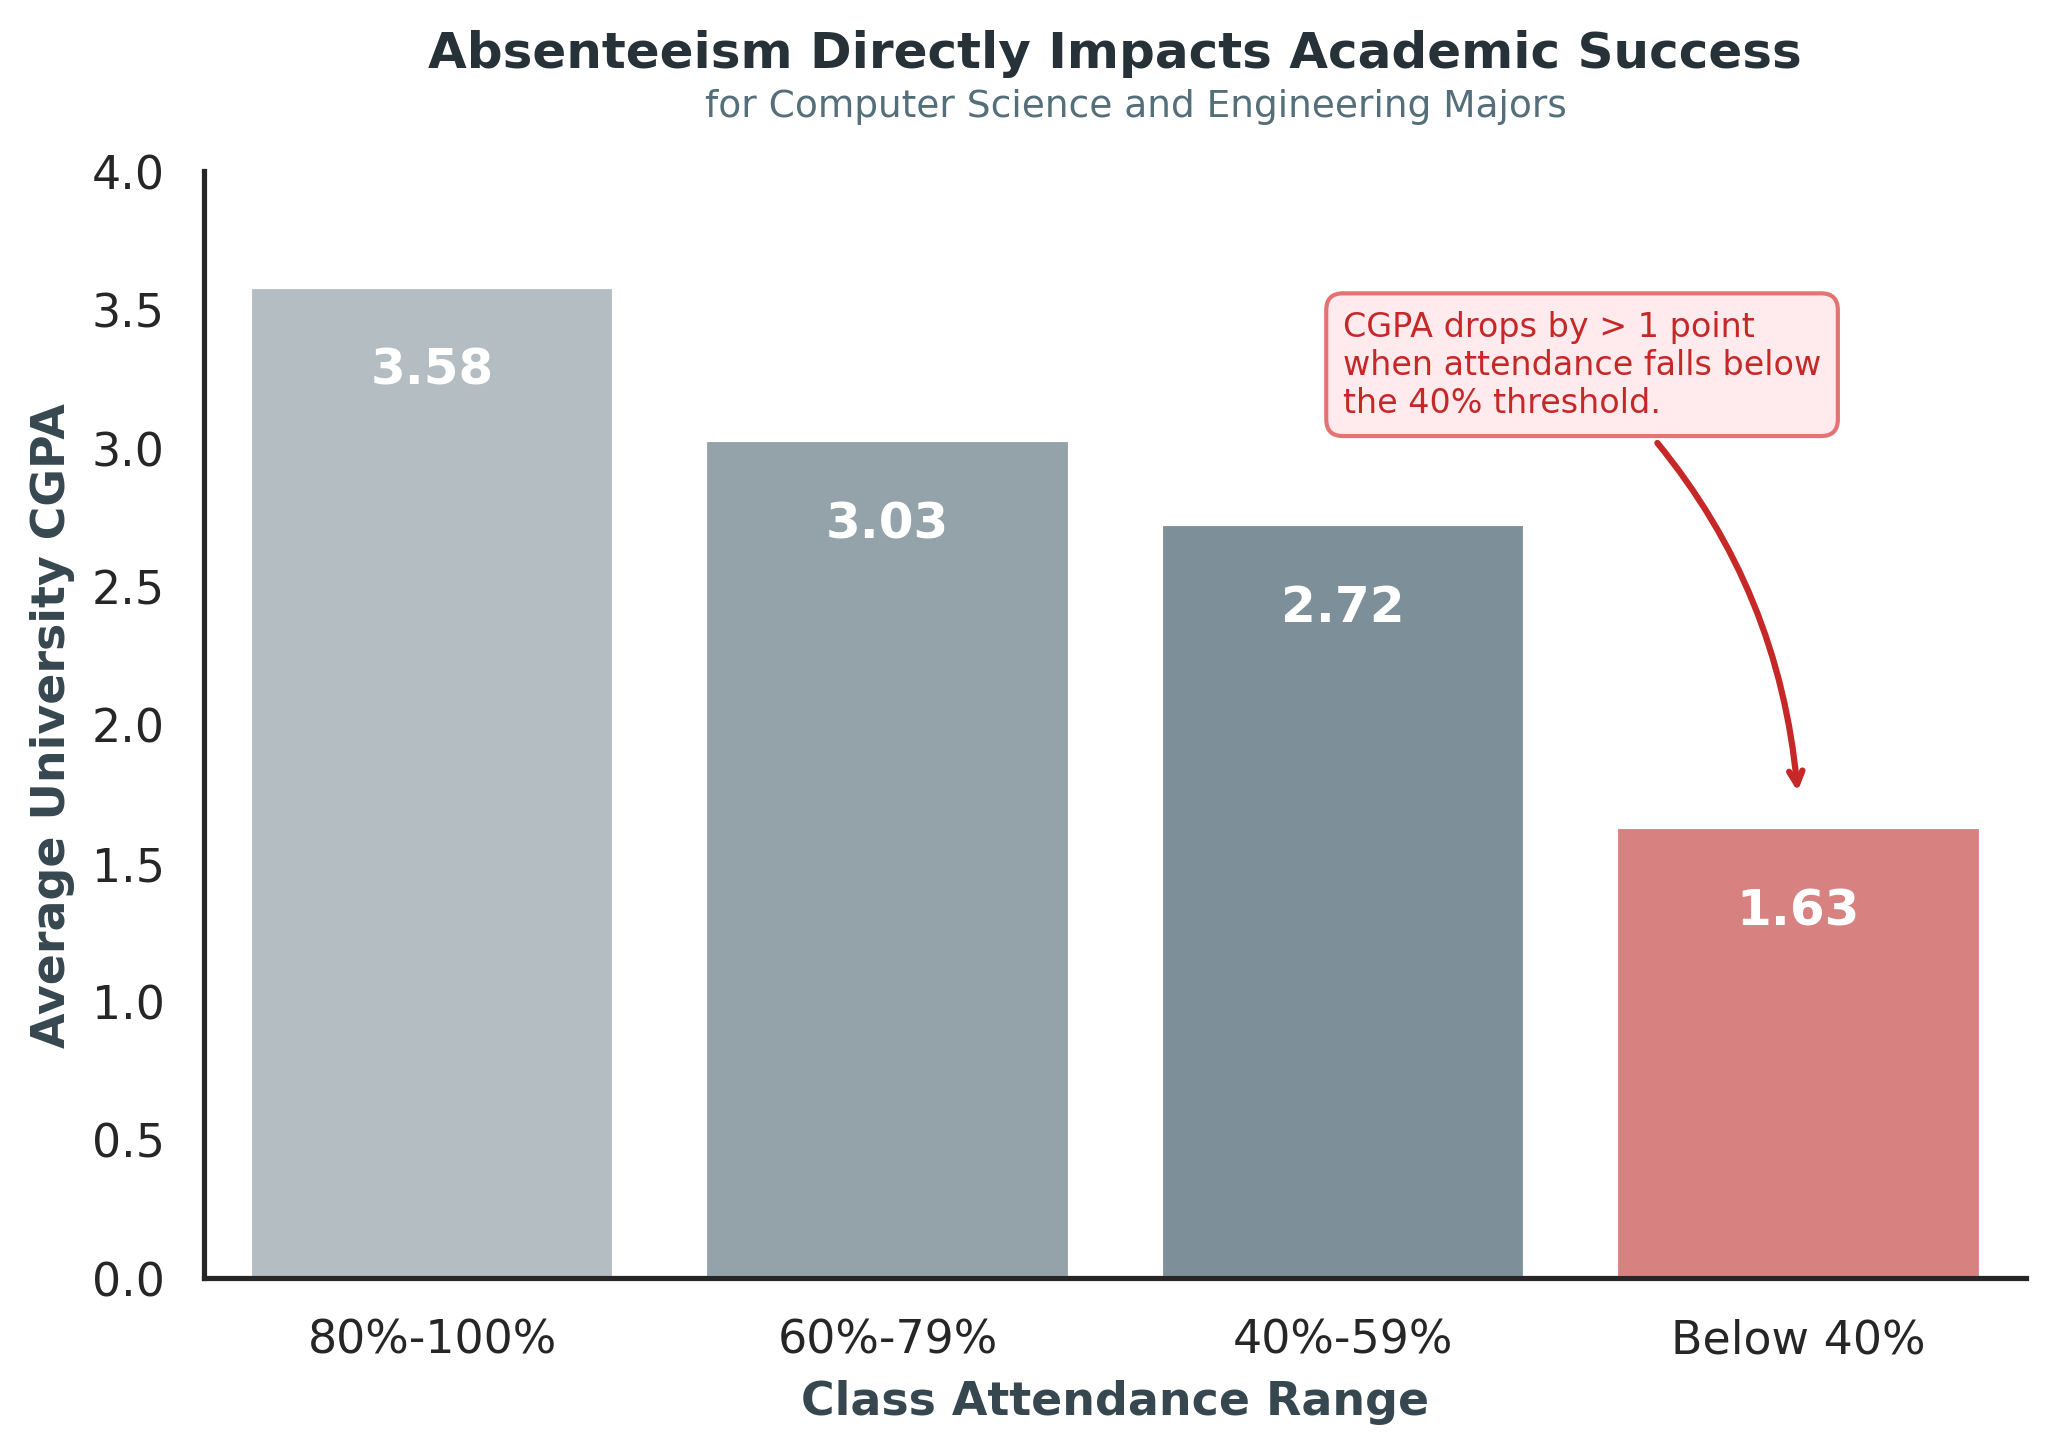

In [10]:
# explanatory
# most data is for the cs department
cs_data = data[data['Department'] == 'Computer Science and Engineering']

# calculate average CGPA for each attendance level
avg_cgpa = cs_data.groupby('Attendance', as_index=False)['Overall'].mean()
avg_cgpa['Attendance'] = pd.Categorical(avg_cgpa['Attendance'], categories=attendance_order, ordered=True)
avg_cgpa = avg_cgpa.sort_values('Attendance').reset_index(drop=True)
print(avg_cgpa)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(7, 5))

explanatory_colors = ['#B0BEC5', '#90A4AE', '#78909C', '#E57373']

sns.barplot(
    x='Attendance', 
    y='Overall', 
    data=avg_cgpa, 
    palette=explanatory_colors,
    hue='Attendance',
    legend=False,
    ax=ax
)

sns.despine()
ax.set_xlabel("Class Attendance Range", fontsize=11, fontweight='bold', color='#37474F')
ax.set_ylabel("Average University CGPA", fontsize=11, fontweight='bold', color='#37474F')

# add direct data labels so there is no guessing the values
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}", 
        (p.get_x() + p.get_width() / 2., p.get_height() - 0.3), # position inside the top of the bar
        ha='center', 
        va='center', 
        xytext=(0, 0), 
        textcoords='offset points',
        fontsize=12,
        fontweight='bold',
        color='white'
    )

ax.set_title(
    "Absenteeism Directly Impacts Academic Success",
    fontsize=12, 
    fontweight='bold', 
    color='#263238',
    pad=25,
    loc='center'
)
 

# subtitle
ax.text(
    x=0.6, 
    y=4.2,
    s="for Computer Science and Engineering Majors",
    fontsize=9, 
    fontweight='normal',
    color='#546E7A',
    transform=ax.transData
)

num_bars = 4
target_bar_index = num_bars - 1 
target_bar_height = avg_cgpa['Overall'].iloc[target_bar_index] if num_bars > 0 else 2.0

ax.annotate(
    "CGPA drops by > 1 point\nwhen attendance falls below\nthe 40% threshold.",
    xy=(target_bar_index, target_bar_height + 0.1),
    xytext=(target_bar_index - 1, target_bar_height + 1.5),
    fontsize=8,
    color='#C62828',
    bbox=dict(boxstyle="round,pad=0.5", fc="#FFEBEE", ec="#E57373", lw=1),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.2",
        color='#C62828',
        lw=1.5
    )
)

# constrain y-axis to GPA scale
ax.set_ylim(0, 4.0)

# save and display!
plt.tight_layout()
image_name = "explanatory"
plt.savefig(f"output/{image_name}.png", dpi=300, bbox_inches='tight')
plt.close()
display(Image(filename=f"output/{image_name}.png"))